# 06 · Interpretabilidad con Grad-CAM
Generamos mapas de calor que muestran **qué regiones** de la radiografía influyeron en la predicción. Sirve para verificar que el modelo atiende anatomía plausible y no artefactos.

In [1]:
# =========================================================
# CONFIGURACIÓN  ·  EDITAR BASE_DIR si hace falta
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# Carpeta de Drive que CONTIENE "Imagenes OK" y "Imagenes Patologicas".
# Ajustá esta ruta a donde estén tus carpetas.
BASE_DIR = '/content/drive/MyDrive/TP_Final Aprendizaje Automatico'

OK_DIR  = os.path.join(BASE_DIR, 'Imagenes OK')
PAT_DIR = os.path.join(BASE_DIR, 'Imagenes Patologicas')

# Carpeta donde se guardará la partición train/val/test (notebook 02)
DATASET_DIR = os.path.join(BASE_DIR, 'dataset')
# Carpeta donde se guardarán los modelos entrenados
MODELS_DIR  = os.path.join(BASE_DIR, 'modelos')
os.makedirs(MODELS_DIR, exist_ok=True)

# Hiperparámetros globales compartidos
IMG_SIZE = (224, 224)
BATCH    = 32
SEED     = 42

# Las carpetas se ordenan alfabéticamente: 'ok'=0, 'patologica'=1
# => la clase POSITIVA (la que nos importa) es 'patologica' = 1
CLASS_NAMES = ['ok', 'patologica']
print('OK_DIR :', OK_DIR)
print('PAT_DIR:', PAT_DIR)

Mounted at /content/drive
OK_DIR : /content/drive/MyDrive/TP_Final Aprendizaje Automatico/Imagenes OK
PAT_DIR: /content/drive/MyDrive/TP_Final Aprendizaje Automatico/Imagenes Patologicas


## 1. Reconstruir test set y cargar el modelo a interpretar

In [2]:
import shutil, tensorflow as tf

# Copiamos la partición de Drive al disco local de Colab (lecturas mucho más rápidas)
LOCAL = '/content/dataset'
if os.path.exists(LOCAL):
    shutil.rmtree(LOCAL)
shutil.copytree(DATASET_DIR, LOCAL)

def make_ds(subset, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        os.path.join(LOCAL, subset),
        labels='inferred', label_mode='int',
        class_names=CLASS_NAMES,
        color_mode='rgb', image_size=IMG_SIZE,
        batch_size=BATCH, shuffle=shuffle, seed=SEED,
    )

train_ds = make_ds('train', shuffle=True)
val_ds   = make_ds('val',   shuffle=False)
test_ds  = make_ds('test',  shuffle=False)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Found 308 files belonging to 2 classes.
Found 66 files belonging to 2 classes.
Found 67 files belonging to 2 classes.


In [3]:
# Interpretamos el mejor modelo (transfer). También funciona con la CNN.
modelo = tf.keras.models.load_model(os.path.join(MODELS_DIR, 'transfer_mobilenetv2.keras'))
modelo.summary()

Model: "transfer_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,988,552 (22.84 MB)

 Trainable params: 1,864,002 (7.11 MB)

 Non-trainable params: 396,544 (1.51 MB)

 Optimizer params: 3,728,006 (14.22 MB)

## 2. Implementación de Grad-CAM

`find_feature_layer` localiza automáticamente el mapa de características a usar:
- En el modelo de **transfer**, la base preentrenada es una sub-red: usamos su salida (mapa de 7×7).
- En la **CNN desde cero**, usamos la última capa `Conv2D`.

In [ ]:
import numpy as np
import tensorflow as tf

def find_feature_layer(model):
    """Devuelve el nombre del mapa de caracteristicas a interpretar.
    - Transfer: la base preentrenada es un sub-modelo -> usamos su salida (7x7).
    - CNN desde cero: la ultima capa Conv2D.
    """
    for layer in reversed(model.layers):          # 1) sub-modelo (base de transfer)
        if isinstance(layer, tf.keras.Model):
            return layer.name
    for layer in reversed(model.layers):          # 2) ultima Conv2D
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError('No se encontro capa de caracteristicas')


def make_gradcam_heatmap(img_array, model, feature_layer_name, pred_index=1):
    """Grad-CAM robusto para modelos con base preentrenada anidada (Keras 3).

    En lugar de construir un Model con la salida simbolica del sub-modelo
    (que en Keras 3 no esta conectada al grafo externo y rompe con KeyError),
    recorremos el modelo capa por capa en una unica pasada conectada:
        pre-base (augmentation/preprocess) -> base (mapas) -> cabezal (logits)
    asi el gradiente fluye desde la clase hasta los mapas de activacion.
    """
    feat = model.get_layer(feature_layer_name)

    capas   = model.layers
    nombres = [c.name for c in capas]
    i_feat  = nombres.index(feature_layer_name)
    pre     = capas[:i_feat]        # input, augmentation, preprocess_input, ...
    cabeza  = capas[i_feat + 1:]    # GAP, dropout, dense, ...

    with tf.GradientTape() as tape:
        x = img_array
        for c in pre:                          # mismo preprocesamiento que predict()
            if not isinstance(c, tf.keras.layers.InputLayer):
                x = c(x, training=False)

        conv_out = feat(x, training=False)     # mapas de activacion (ej. 7x7x1280)
        tape.watch(conv_out)                   # observar el tensor concreto

        h = conv_out
        for c in cabeza:                       # mismo grafo -> gradiente conectado
            h = c(h, training=False)
        class_channel = h[:, pred_index]       # prob. clase patologica (softmax)

    # Gradiente de la clase respecto al mapa, y pooling -> peso por filtro
    grads  = tape.gradient(class_channel, conv_out)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]                      # quitar dimension de batch
    heatmap  = conv_out @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap)
    heatmap  = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


FEATURE_LAYER = find_feature_layer(modelo)
print('Capa de caracteristicas:', FEATURE_LAYER)

Capa de caracteristicas: mobilenetv2_1.00_224


## 3. Superponer el mapa de calor sobre la imagen

In [ ]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

def mostrar_gradcam(img, modelo, feature_layer, alpha=0.4):
    arr = tf.expand_dims(tf.cast(img, tf.float32), 0)     # el modelo preprocesa internamente
    prob = float(modelo.predict(arr, verbose=0)[0, 1])
    heatmap = make_gradcam_heatmap(arr, modelo, feature_layer)

    heatmap_rs = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    color = cm.jet(heatmap_rs)[..., :3]
    base = img.numpy().astype('float32') / 255.0
    overlay = (1 - alpha) * base + alpha * color

    pred = 'patologica' if prob >= 0.5 else 'ok'
    fig, ax = plt.subplots(1, 3, figsize=(11, 4))
    ax[0].imshow(base); ax[0].set_title('Original')
    ax[1].imshow(heatmap_rs, cmap='jet'); ax[1].set_title('Grad-CAM')
    ax[2].imshow(overlay); ax[2].set_title(f'Pred: {pred} (p={prob:.2f})')
    for a in ax: a.axis('off')
    plt.tight_layout(); plt.show()

## 4. Ejemplos: aciertos y errores

TP: 11 | FN: 19 | FP: 10
FEATURE_LAYER = mobilenetv2_1.00_224

Verdadero positivo (patologia bien detectada):


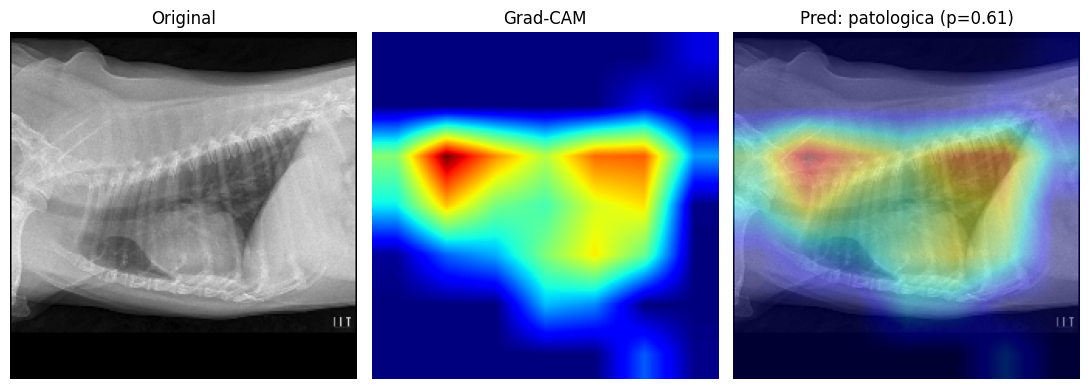


Falso negativo (patologia NO detectada):


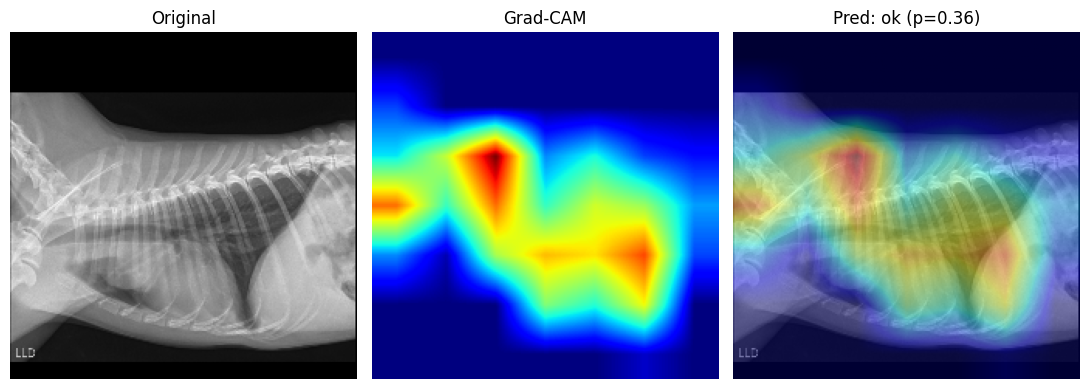


Falso positivo (falsa alarma):


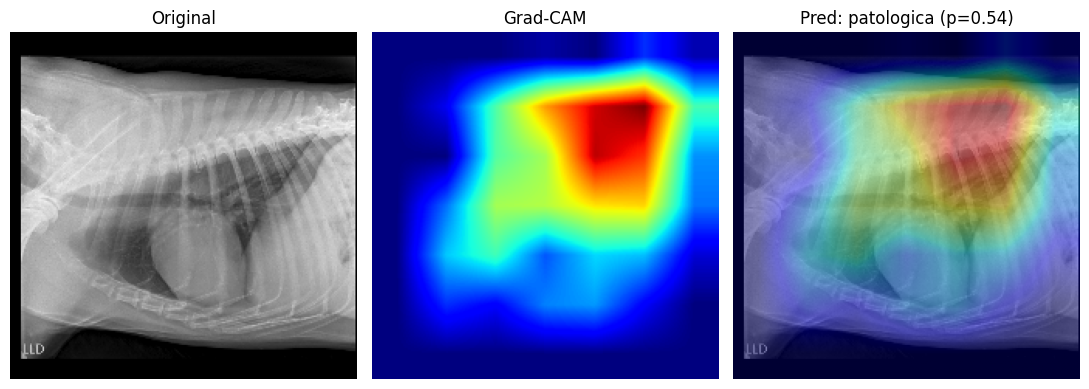

In [ ]:
# Reconstruir imgs / labels / preds desde el test set (sin shuffle)
imgs, labels = [], []
for bx, by in test_ds.unbatch():
    imgs.append(bx)
    labels.append(int(by.numpy().ravel()[0]))
labels = np.array(labels)

probs = modelo.predict(test_ds, verbose=0)[:, 1]   # prob. de 'patologica'
preds = (probs >= 0.5).astype(int)

# Indices de casos representativos
idx_tp = np.where((labels == 1) & (preds == 1))[0]   # patologia detectada
idx_fn = np.where((labels == 1) & (preds == 0))[0]   # patologia NO detectada (critico)
idx_fp = np.where((labels == 0) & (preds == 1))[0]   # falsa alarma
print('TP:', len(idx_tp), '| FN:', len(idx_fn), '| FP:', len(idx_fp))
print('FEATURE_LAYER =', FEATURE_LAYER)

# Mostrar un caso de cada tipo
print('\nVerdadero positivo (patologia bien detectada):')
if len(idx_tp): mostrar_gradcam(imgs[idx_tp[0]], modelo, FEATURE_LAYER)

print('\nFalso negativo (patologia NO detectada):')
if len(idx_fn): mostrar_gradcam(imgs[idx_fn[0]], modelo, FEATURE_LAYER)

print('\nFalso positivo (falsa alarma):')
if len(idx_fp): mostrar_gradcam(imgs[idx_fp[0]], modelo, FEATURE_LAYER)

## 5. Análisis

> **Completar:** ¿el modelo se enfoca en regiones anatómicas plausibles (campos pulmonares, silueta cardíaca) o en bordes/artefactos? Comparar los casos bien clasificados con los errores. Insertar estas figuras en la sección 5 del informe.

Para interpretar también la **CNN desde cero**, cargá su `.keras` en la celda de arriba: el resto funciona igual.